### Primeira vers'ao do pipeline


#  Dataset



https://www.kaggle.com/datasets/crawford/deepsat-sat6/data


*Objetivo: Desenvolver um algoritmo capaz de classificar automaticamente imagens de sensoriamento remoto em
suas respectivas categorias. Classes presentes no dataset*:

• Building;

• Barren Land;

• Trees;

• Grassland;

• Roads;

• Water Bodies.

Principais desafios:
- Alta variabilidade intra-classe;
- Semelhança visual entre algumas categorias;
- Presença de informações multiespectrais;
- Variações de iluminação e cobertura do terreno.

Métricas:

- Acurácia;
- Precisão;
- Revocação (Recall);
- F1-Score;
- Matriz de Confusão.

Caso o dataset escolhido não possua divisão oficial entre treinamento e teste, assumir:
- 80% das imagens para treinamento;
- 20% das imagens para teste.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



In [15]:
## pega todas as imagnes
# ds_imgs_4d_train = pd.read_csv('data/ds_train/X_train_sat6.csv', header=None)
# ds_label_train = pd.read_csv('data/ds_train/y_train_sat6.csv', header=None)


ds_10_img = pd.read_csv('data/ds_train/X_train_sat6.csv', header=None, nrows=100)
ds_10_lbl = pd.read_csv('data/ds_train/y_train_sat6.csv', header=None, nrows=100)

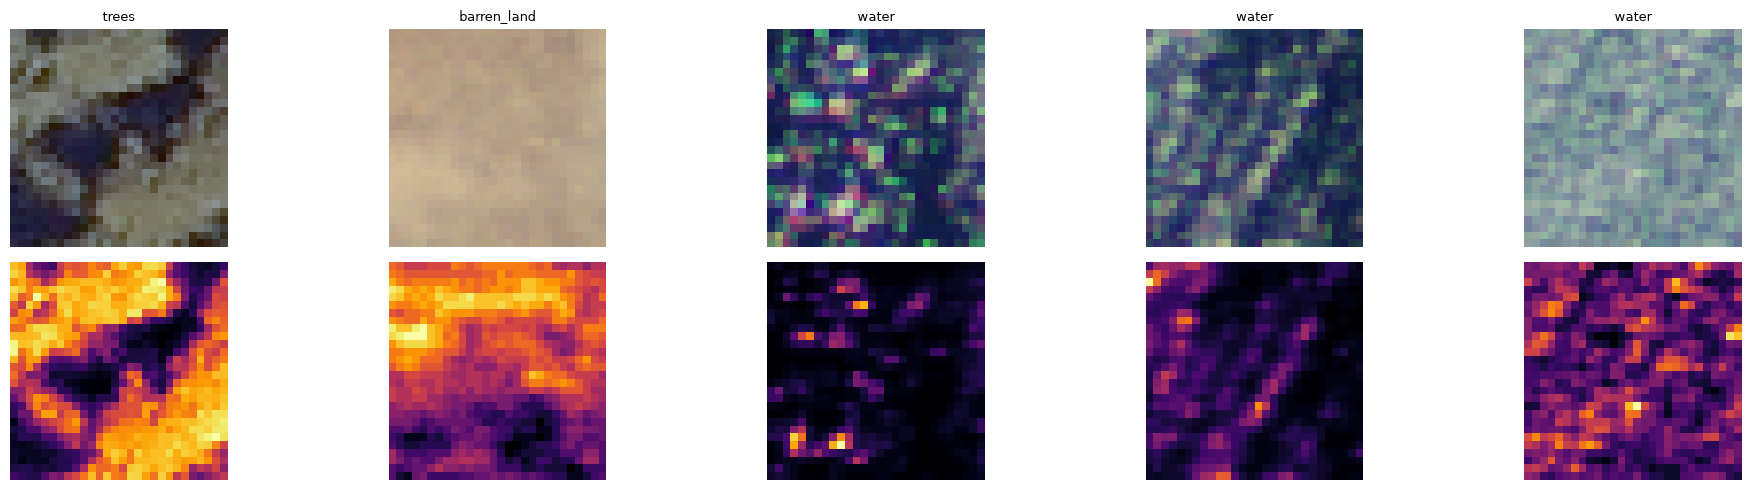

In [16]:
classes = ['building', 'barren_land', 'trees', 'grassland', 'road', 'water']
classes_pt = ['Construção', 'Terra Árida ', 'Árvores', 'Pastagens', 'Rodovia', 'Agua']

images = ds_10_img.values.reshape(-1, 28, 28, 4)
rgb_images = images[:, :, :, :3]      # canais 0,1,2 = R, G, B
ir_images = images[:, :, :, 3]        # canal 3 = infravermelho



fig, axes = plt.subplots(2, 5, figsize=(20, 5))

for i in range(5):
    label_idx = np.argmax(ds_10_lbl.iloc[i].values)
    
    # RGB
    axes[0, i].imshow(rgb_images[i].astype(np.uint8))
    axes[0, i].set_title(classes[label_idx], fontsize=9)
    axes[0, i].axis('off')
    
    axes[1, i].imshow(ir_images[i], cmap='inferno')
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('RGB', fontsize=12)
axes[1, 0].set_ylabel('Infravermelho', fontsize=12)

plt.tight_layout()
plt.show()

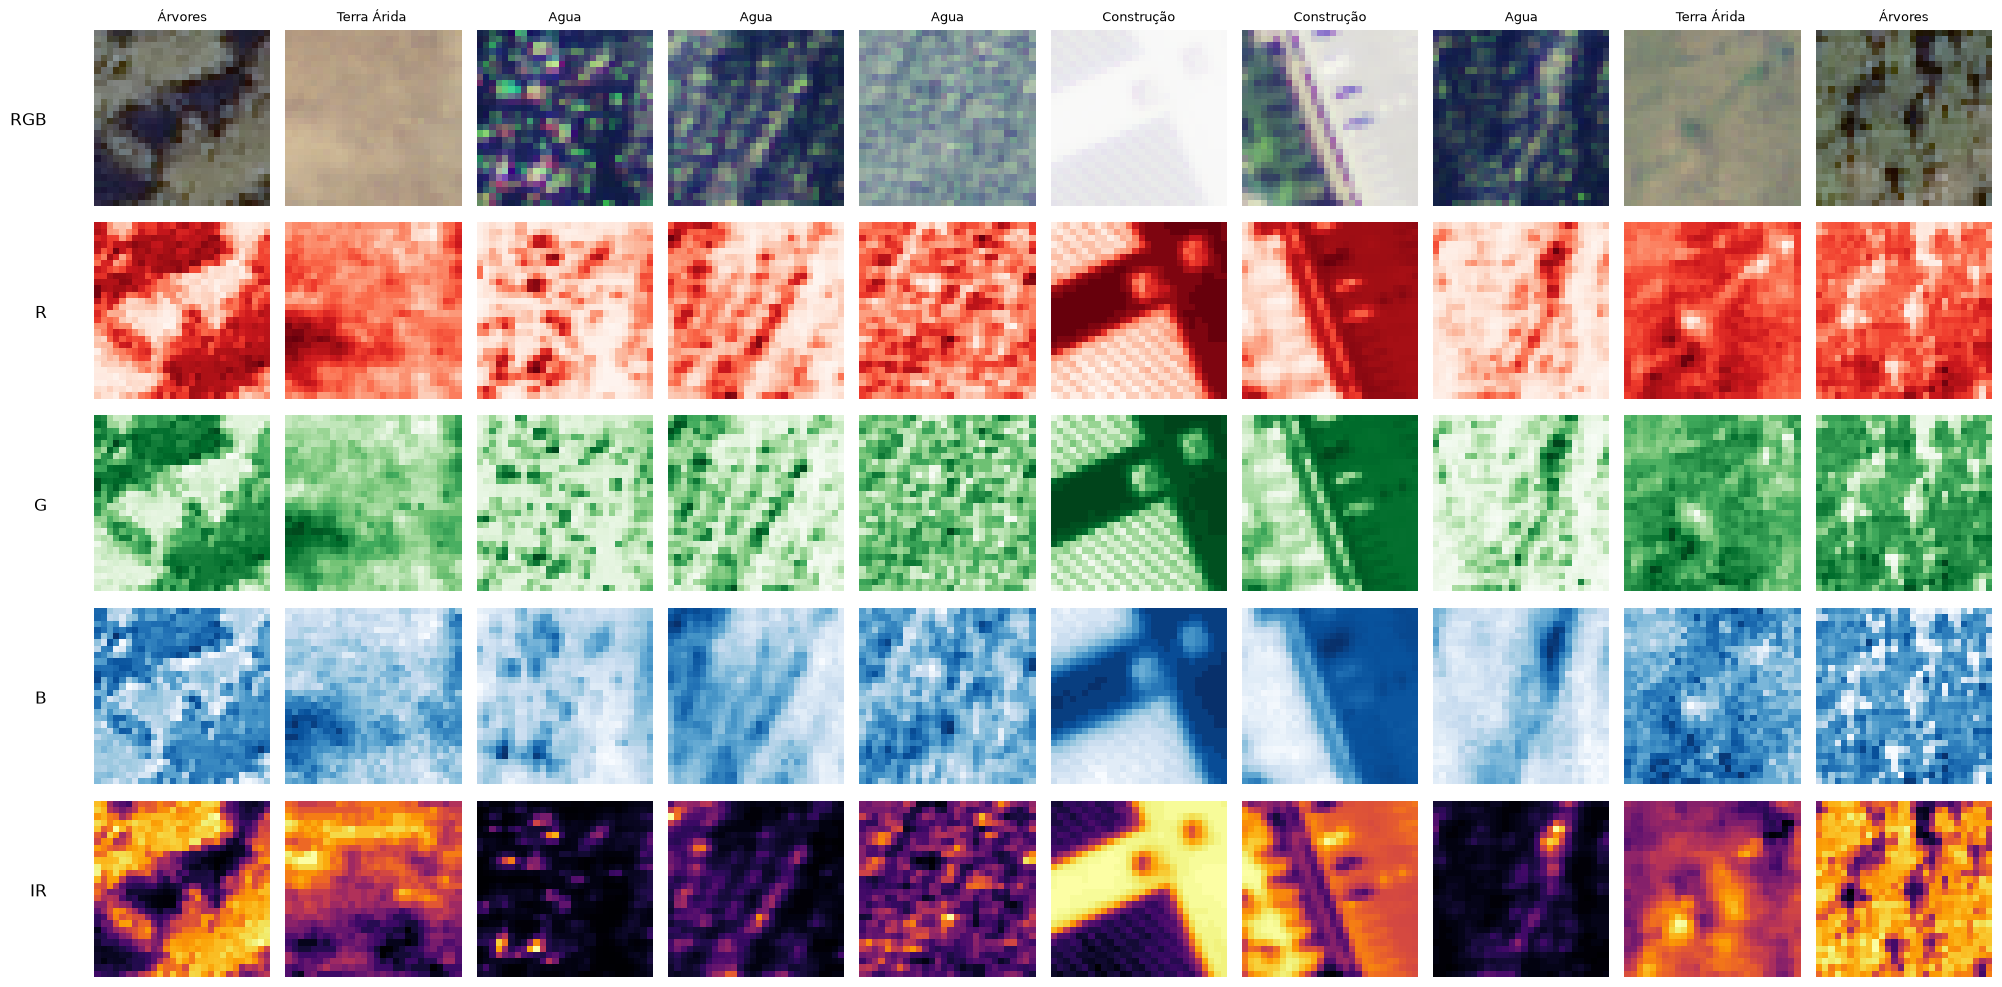

In [14]:
# Separar cada canal
r_channel = images[:, :, :, 0]
g_channel = images[:, :, :, 1]
b_channel = images[:, :, :, 2]
ir_channel = images[:, :, :, 3]
rgb_images = images[:, :, :, :3]

# Plot: 5 linhas (RGB combinado, R, G, B, IR) x 10 colunas
fig, axes = plt.subplots(5, 10, figsize=(20, 10))

row_labels = ['RGB', 'R', 'G', 'B', 'IR']

for i in range(10):
    label_idx = np.argmax(ds_10_lbl.iloc[i].values)
    
    axes[0, i].imshow(rgb_images[i].astype(np.uint8))
    axes[0, i].set_title(classes_pt[label_idx], fontsize=9)
    
    axes[1, i].imshow(r_channel[i], cmap='Reds')
    axes[2, i].imshow(g_channel[i], cmap='Greens')
    axes[3, i].imshow(b_channel[i], cmap='Blues')
    axes[4, i].imshow(ir_channel[i], cmap='inferno')
    
    for row in range(5):
        axes[row, i].axis('off')

# Labels nas linhas
for row in range(5):
    axes[row, 0].text(-8, 14, row_labels[row], fontsize=12, 
                       ha='right', va='center', rotation=0)

plt.tight_layout()
plt.show()

### Rereferencias

1. https://www.kaggle.com/code/agajorte/sat-6-aerial-images-classification
- As 2 celulas abaixo, contem um plot completo com historigrama e todos o canais (n rodou)
- na cel93 ele cria o primeiro modelo, create_model1().  na 94 executa
- O autor cria 6 modelos
- trabalho praticamente inteiro ali, feito com cnn. ha varios graficos de comparacao


2. https://scispace.com/pdf/deepsat-a-learning-framework-for-satellite-imagery-50pu4edguh.pdf
3. https://github.com/markbarna/DeepSat6-Image-Classification/blob/master/mark-barna-final-project.pdf
- Fundamentacao teorica.


In [29]:
def show_histogram_samples(data, labels):
    class_count = 6
    class_names  = ['building', 'barren_land', 'trees', 'grassland', 'road', 'water']

    # buscar uma amostra de cada classe
    sample_indices = []
    class_counter = 0
    while class_counter < class_count:
        index = np.random.randint(1, 100)
        class_number = labels.iloc[index, 0] 
            
        print(index, type(index))
        print(class_number, type(class_number))
        print(class_counter, type(class_counter))
        if class_number == class_counter:
            class_counter += 1
            sample_indices.append(index)
            continue
    print("sample indices:", sample_indices)

    colors = ("red", "green", "blue", "purple")
    channel_ids = (0, 1, 2, 3)

    fig = plt.figure(figsize=(18, 12))
    ax = []
    rows, columns = 6, 6
    class_counter = 0

    # plotar imagem RGB, canais separados e histograma de cada classe
    for i in range(rows):
        index = sample_indices[class_counter]
        class_counter += 1
        all = data[index].reshape([28,28,4])
        
        class_name = class_names[labels.iloc[index]]  

        rgb = all[:,:,:3]
        ax.append(fig.add_subplot(rows, columns, i * columns + 1))
        ax[-1].set_title(class_name)
        plt.axis("off")
        plt.imshow(rgb)
        plt.colorbar()

        red = all[:,:,0]
        ax.append(fig.add_subplot(rows, columns, i * columns + 2))
        ax[-1].set_title("Red")
        plt.axis("off")
        plt.imshow(red, cmap="Reds")
        plt.colorbar()

        green = all[:,:,1]
        ax.append(fig.add_subplot(rows, columns, i * columns + 3))
        ax[-1].set_title("Green")
        plt.axis("off")
        plt.imshow(green, cmap="Greens")
        plt.colorbar()

        blue = all[:,:,2]
        ax.append(fig.add_subplot(rows, columns, i * columns + 4))
        ax[-1].set_title("Blue")
        plt.axis("off")
        plt.imshow(blue, cmap="Blues")
        plt.colorbar()

        nir = all[:,:,2]
        ax.append(fig.add_subplot(rows, columns, i * columns + 5))
        ax[-1].set_title("NIR")
        plt.axis("off")
        plt.imshow(nir, cmap="inferno")
        plt.colorbar()

        ax.append(fig.add_subplot(rows, columns, i * columns + 6))
        ax[-1].set_xlim([0, 256])
        for channel_id, c in zip(channel_ids, colors):
            histogram, bin_edges = np.histogram(
                all[:, :, channel_id], bins=256, range=(0, 256))
            ax[-1].plot(bin_edges[0:-1], histogram, color=c, linewidth=0.8)

    fig.tight_layout()

    #plt.subplots_adjust(wspace=0.1, hspace=0.5)
    plt.show()

In [28]:
show_histogram_samples(ds_10_img, ds_10_lbl)

22 <class 'int'>
0    0
1    1
2    0
3    0
4    0
5    0
Name: 22, dtype: int64 <class 'pandas.Series'>
0 <class 'int'>


ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

In [23]:
def show_histogram_samples2(data, labels):
    class_count = 6
    class_names = ['building', 'barren_land', 'trees', 'grassland', 'road', 'water']
    sample_indices = []
    class_counter = 0
    while class_counter < class_count:
        index = np.random.randint(1, 100)
        class_number = labels.iloc[index]              # .iloc em vez de []
        if int(class_number) == class_counter:
            class_counter += 1
            sample_indices.append(index)
            continue

    print("sample indices:", sample_indices)
    colors = ("red", "green", "blue", "purple")
    channel_ids = (0, 1, 2, 3)
    fig = plt.figure(figsize=(18, 12))
    ax = []
    rows, columns = 6, 6
    class_counter = 0

    for i in range(rows):
        index = sample_indices[class_counter]
        class_counter += 1
        all = data[index].reshape([28, 28, 4])          # data.iloc[index] se também for pandas
        class_name = class_names[labels.iloc[index]]    # .iloc em vez de []
        rgb = all[:, :, :3]
        ax.append(fig.add_subplot(rows, columns, i * columns + 1))
        ax[-1].set_title(class_name)
        plt.axis("off")
        plt.imshow(rgb)
        plt.colorbar()

        red = all[:, :, 0]
        ax.append(fig.add_subplot(rows, columns, i * columns + 2))
        ax[-1].set_title("Red")
        plt.axis("off")
        plt.imshow(red, cmap="Reds")
        plt.colorbar()

        green = all[:, :, 1]
        ax.append(fig.add_subplot(rows, columns, i * columns + 3))
        ax[-1].set_title("Green")
        plt.axis("off")
        plt.imshow(green, cmap="Greens")
        plt.colorbar()

        blue = all[:, :, 2]
        ax.append(fig.add_subplot(rows, columns, i * columns + 4))
        ax[-1].set_title("Blue")
        plt.axis("off")
        plt.imshow(blue, cmap="Blues")
        plt.colorbar()

        nir = all[:, :, 3]                              # 3, não 2
        ax.append(fig.add_subplot(rows, columns, i * columns + 5))
        ax[-1].set_title("NIR")
        plt.axis("off")
        plt.imshow(nir, cmap="inferno")
        plt.colorbar()

        ax.append(fig.add_subplot(rows, columns, i * columns + 6))
        ax[-1].set_xlim([0, 256])
        for channel_id, c in zip(channel_ids, colors):
            histogram, bin_edges = np.histogram(all[:, :, channel_id], bins=256, range=(0, 256))
            ax[-1].plot(bin_edges[0:-1], histogram, color=c, linewidth=0.8)

    fig.tight_layout()
    plt.show()

In [24]:
show_histogram_samples2(ds_10_img, ds_10_lbl)

TypeError: int() argument must be a string, a bytes-like object or a real number, not 'Series'